In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sentence_transformers import SentenceTransformer

import ast
import csv

from config import (
    dataset_dir, 
    dataset_name, 
    dataset_cleaned_name, 
    dataset_preprocessed_name, 
)

### 1. Общая информация

In [140]:
df = pd.read_csv(
    filepath_or_buffer=dataset_dir / dataset_name, 
    delimiter=';', 
    engine='python', 
    quoting=csv.QUOTE_NONE
)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27159 entries, 0 to 27158
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 27149 non-null  str    
 1   title              27149 non-null  str    
 2   original_title     27149 non-null  str    
 3   overview           27027 non-null  str    
 4   original_language  27147 non-null  str    
 5   genres             27157 non-null  str    
 6   popularity         27133 non-null  float64
 7   release_date       27100 non-null  str    
 8   vote_average       27131 non-null  float64
 9   vote_count         27131 non-null  float64
dtypes: float64(3), str(7)
memory usage: 11.1 MB


### 2. Про-пуски

Overview column contains lots of NAs, so some info for them could be provided. Other NAs are negligible, so they are droped.

In [141]:
df = df.fillna({'overview': 'Not provided'}).dropna()

### 3. Дубликаты

Дубликаты. Их нет, но для вида можно и написать строчку

In [142]:
df.drop_duplicates(inplace=True)

In [143]:
df['release_year'] = df['release_date'].apply(lambda x: int(x.split('-')[0]))
df = df.drop('release_date', axis=1)

df['vote_count'] = df['vote_count'].astype(int)

df['genres'] = df['genres'].apply(
    lambda x: ast.literal_eval(x)
)

df['id'] = df['id'].astype(float).astype(int)
df.set_index('id', inplace=True)

In [144]:
df.info()

<class 'pandas.DataFrame'>
Index: 26952 entries, 472027 to 514668
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              26952 non-null  str    
 1   original_title     26952 non-null  str    
 2   overview           26952 non-null  str    
 3   original_language  26952 non-null  str    
 4   genres             26952 non-null  object 
 5   popularity         26952 non-null  float64
 6   vote_average       26952 non-null  float64
 7   vote_count         26952 non-null  int64  
 8   release_year       26952 non-null  int64  
dtypes: float64(2), int64(2), object(1), str(4)
memory usage: 9.9+ MB


In [145]:
df.head()

,title,original_title,overview,original_language,genres,popularity,vote_average,vote_count,release_year
id,,,,,,,,,
472027,Batman: The Dark Knight Returns,Batman: The Dark Knight Returns,Batman has not been seen for ten years. A new ...,en,"[Animation, Action, Science Fiction, Mystery]",5.3865,8.112,165,2013
828898,The Venture Bros.: Radiant Is the Blood of the...,The Venture Bros.: Radiant Is the Blood of the...,A nationwide manhunt for Hank Venture leads to...,en,"[Adventure, Animation, Action, Science Fiction]",4.7444,7.300,96,2023
394355,Hulk Vs.,Hulk Vs.,Two stories featuring Marvel's anti-hero: .......,en,"[Adventure, Fantasy, Animation, Action, Scienc...",3.0927,6.648,244,2009
640810,DC Showcase Original Shorts Collection,DC Showcase Original Shorts Collection,An anthology of DC Showcase stories consisting...,en,"[Adventure, Fantasy, Animation, Action, Scienc...",2.4793,7.000,40,2010
13204,Hellboy Animated: Blood and Iron,Hellboy Animated: Blood and Iron,"When Hellboy, Liz Sherman, and Abe Sapien are ...",en,"[Fantasy, Animation, Horror, Action, Thriller,...",3.7750,6.349,156,2007


In [146]:
df.to_pickle(dataset_dir / dataset_cleaned_name)

### 4. Выбросы

In [147]:
numeric_df = df.select_dtypes(include='number')
numeric_df.head()

,popularity,vote_average,vote_count,release_year
id,,,,
472027,5.3865,8.112,165,2013
828898,4.7444,7.300,96,2023
394355,3.0927,6.648,244,2009
640810,2.4793,7.000,40,2010
13204,3.7750,6.349,156,2007


In [148]:
sns.set_theme()

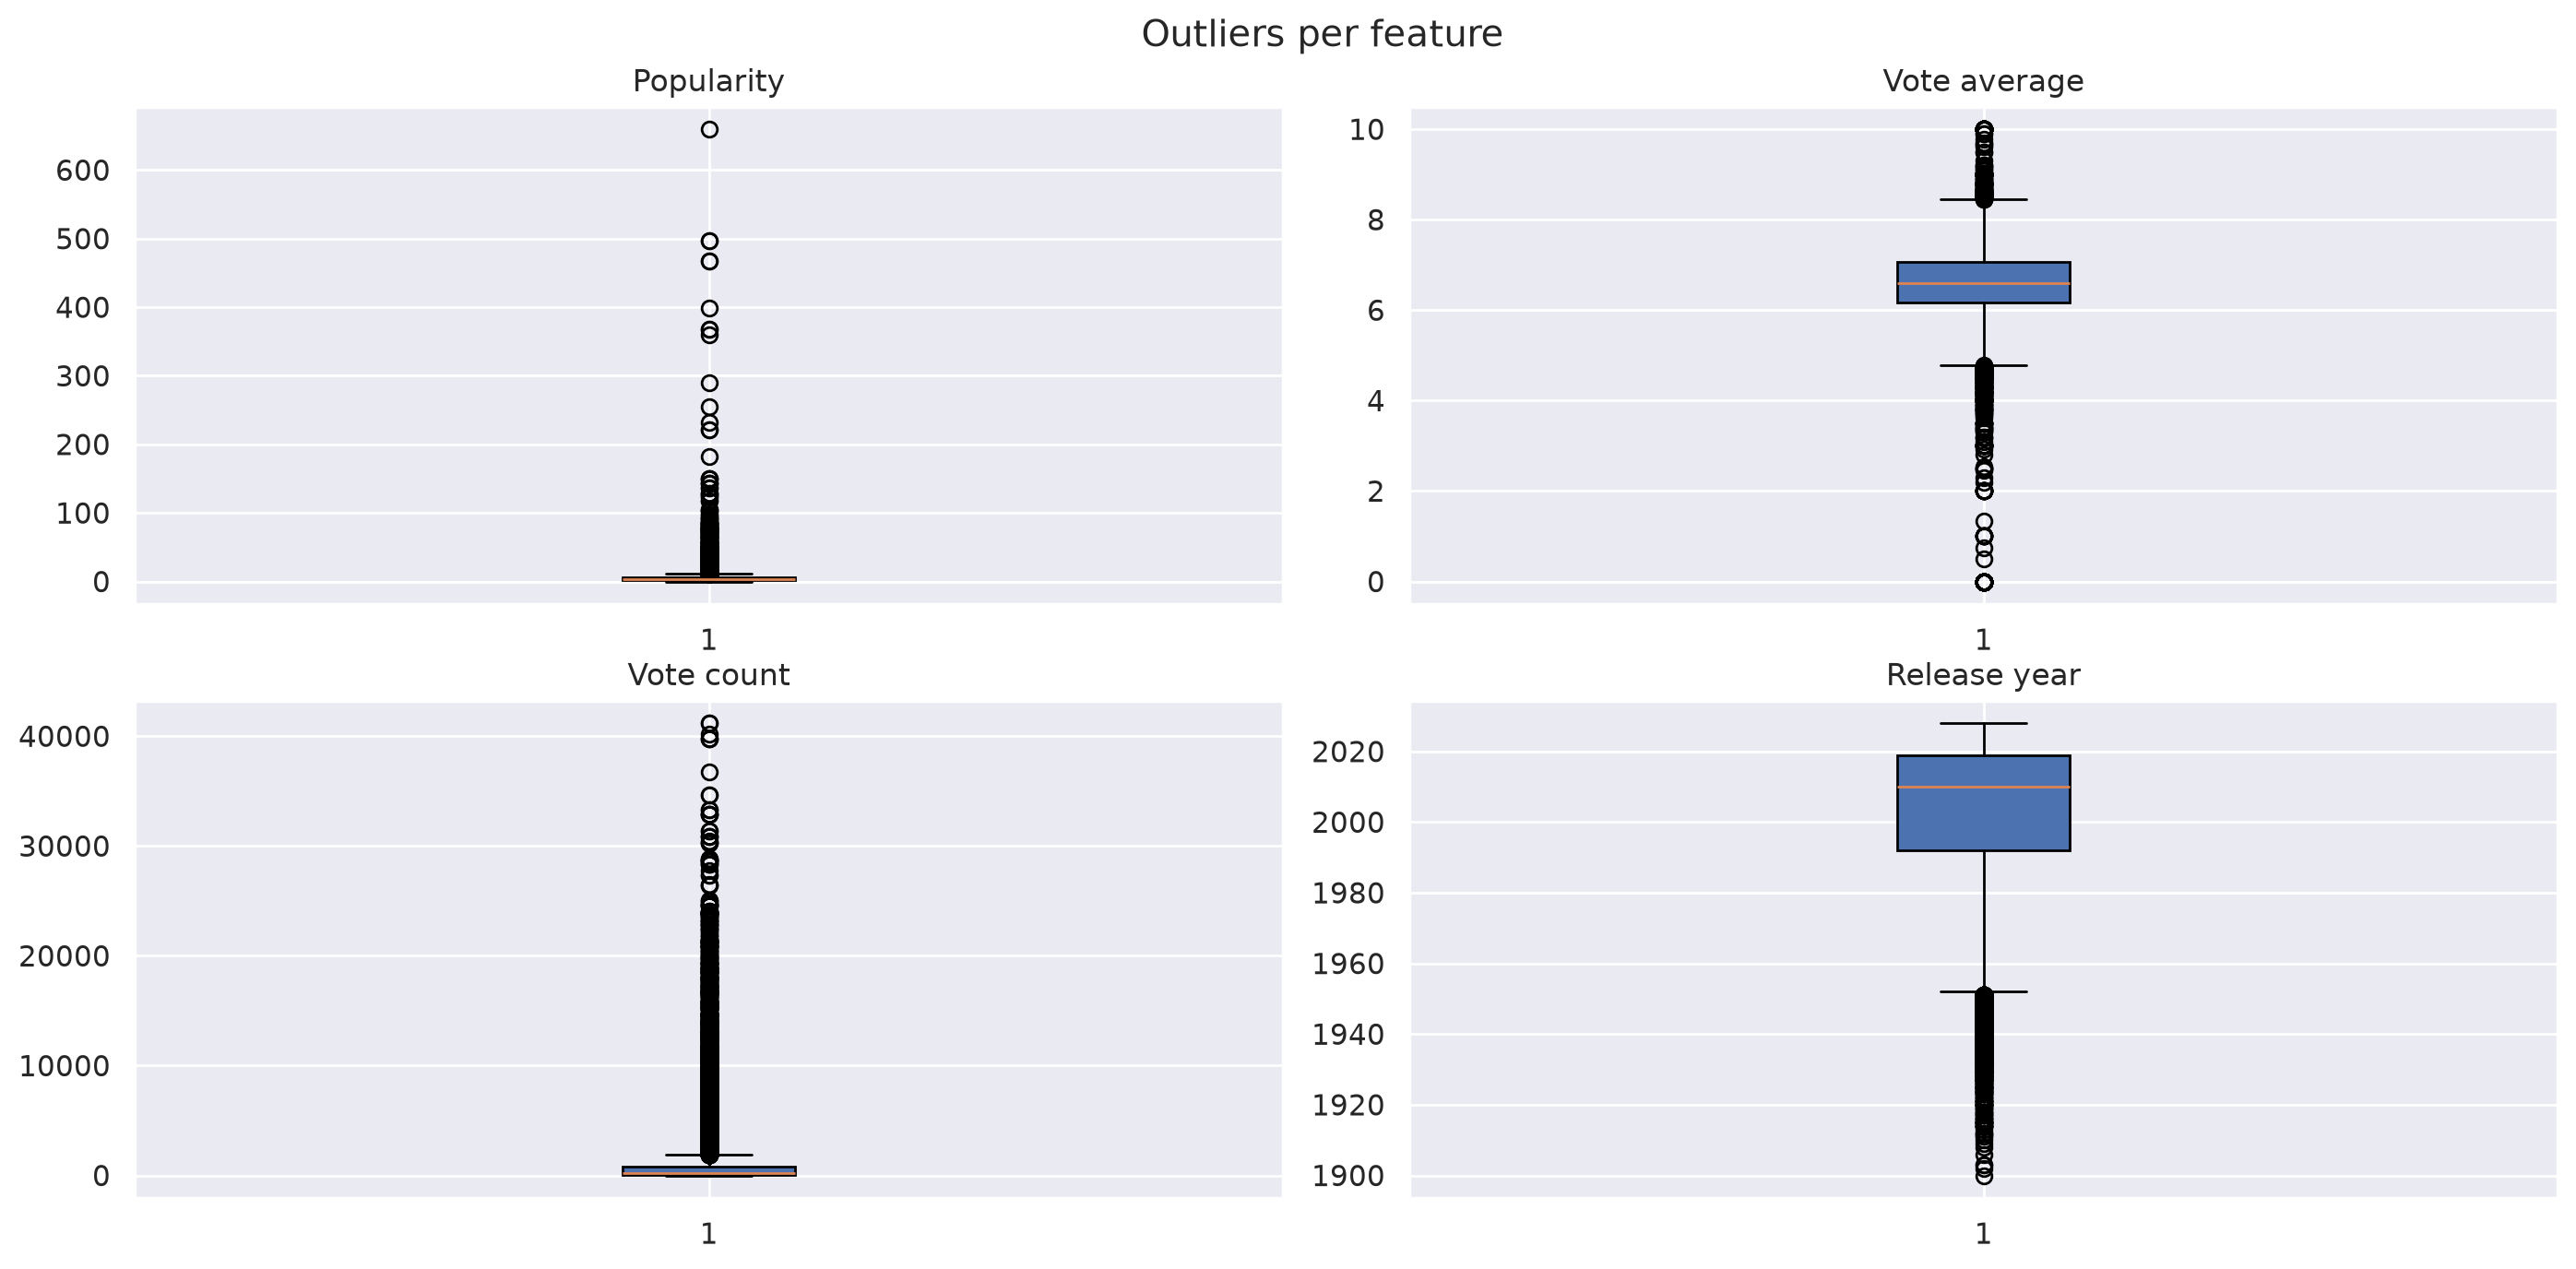

In [149]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), dpi=200)
axes = axes.flatten()

fig.suptitle('Outliers per feature')
plt.tight_layout()

for i, column_name in enumerate(numeric_df.columns):
    axes[i].set_title(column_name.capitalize().replace('_', ' '))
    axes[i].boxplot(numeric_df[column_name], patch_artist=True)

plt.show()


### 5. Кодирование

Над усами много данных - их (не усы) можно сжать через логирифмы

In [150]:
df['popularity_log'] = df['popularity'].apply(lambda x: np.log(x + 1))
df['vote_count_log'] = df['vote_count'].apply(lambda x: np.log(x + 1))

df.drop(columns=['popularity', 'vote_count'], inplace=True)

In [151]:
scaler = StandardScaler()

numeric_columns = df.select_dtypes(include=['int', 'float']).columns
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

for column_name in numeric_columns:
    df[f'{column_name}_norm'] = df[column_name]
    df.drop(columns=[column_name], inplace=True)

df.head()

,title,original_title,overview,original_language,genres,vote_average_norm,release_year_norm,popularity_log_norm,vote_count_log_norm
id,,,,,,,,,
472027,Batman: The Dark Knight Returns,Batman: The Dark Knight Returns,Batman has not been seen for ten years. A new ...,en,"[Animation, Action, Science Fiction, Mystery]",1.480033,0.483563,0.273992,-0.250526
828898,The Venture Bros.: Radiant Is the Blood of the...,The Venture Bros.: Radiant Is the Blood of the...,A nationwide manhunt for Hank Venture leads to...,en,"[Adventure, Animation, Action, Science Fiction]",0.710353,0.929414,0.103787,-0.553464
394355,Hulk Vs.,Hulk Vs.,Two stories featuring Marvel's anti-hero: .......,en,"[Adventure, Fantasy, Animation, Action, Scienc...",0.092334,0.305223,-0.440782,-0.031040
640810,DC Showcase Original Shorts Collection,DC Showcase Original Shorts Collection,An anthology of DC Showcase stories consisting...,en,"[Adventure, Fantasy, Animation, Action, Scienc...",0.425988,0.349808,-0.701603,-1.039007
13204,Hellboy Animated: Blood and Iron,Hellboy Animated: Blood and Iron,"When Hellboy, Liz Sherman, and Abe Sapien are ...",en,"[Fantasy, Animation, Horror, Action, Thriller,...",-0.191083,0.216053,-0.193108,-0.281955


In [152]:
label_encoder = LabelEncoder()
language_codes = label_encoder.fit_transform(df['original_language'])

df['language_code'] = language_codes # type: ignore
df.drop(columns='original_language', inplace=True)

In [153]:
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genres'])
df['genres_multihot'] = list(genres_encoded) # type: ignore
df.drop(columns=['genres'], inplace=True)
df.head()

,title,original_title,overview,vote_average_norm,release_year_norm,popularity_log_norm,vote_count_log_norm,language_code,genres_multihot
id,,,,,,,,,
472027,Batman: The Dark Knight Returns,Batman: The Dark Knight Returns,Batman has not been seen for ten years. A new ...,1.480033,0.483563,0.273992,-0.250526,11,"[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, ..."
828898,The Venture Bros.: Radiant Is the Blood of the...,The Venture Bros.: Radiant Is the Blood of the...,A nationwide manhunt for Hank Venture leads to...,0.710353,0.929414,0.103787,-0.553464,11,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
394355,Hulk Vs.,Hulk Vs.,Two stories featuring Marvel's anti-hero: .......,0.092334,0.305223,-0.440782,-0.031040,11,"[1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ..."
640810,DC Showcase Original Shorts Collection,DC Showcase Original Shorts Collection,An anthology of DC Showcase stories consisting...,0.425988,0.349808,-0.701603,-1.039007,11,"[1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ..."
13204,Hellboy Animated: Blood and Iron,Hellboy Animated: Blood and Iron,"When Hellboy, Liz Sherman, and Abe Sapien are ...",-0.191083,0.216053,-0.193108,-0.281955,11,"[1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ..."


In [154]:
encoder = SentenceTransformer('all-MiniLM-L6-v2')

strings_df = df.select_dtypes(include='str')

for column_name in strings_df.columns:
    embeddings = encoder.encode(
        df[column_name].tolist(),
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    df[f'{column_name}_embeddings'] = embeddings.tolist() # type: ignore
    df.drop(columns=[column_name], inplace=True)

df.info()

Batches: 100%|██████████| 843/843 [00:21<00:00, 39.38it/s]


<class 'pandas.DataFrame'>
Index: 26952 entries, 472027 to 514668
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   vote_average_norm          26952 non-null  float64
 1   release_year_norm          26952 non-null  float64
 2   popularity_log_norm        26952 non-null  float64
 3   vote_count_log_norm        26952 non-null  float64
 4   language_code              26952 non-null  int64  
 5   genres_multihot            26952 non-null  object 
 6   title_embeddings           26952 non-null  object 
 7   original_title_embeddings  26952 non-null  object 
 8   overview_embeddings        26952 non-null  object 
dtypes: float64(4), int64(1), object(4)
memory usage: 2.1+ MB


In [155]:
df.head()

,vote_average_norm,release_year_norm,popularity_log_norm,vote_count_log_norm,language_code,genres_multihot,title_embeddings,original_title_embeddings,overview_embeddings
id,,,,,,,,,
472027,1.480033,0.483563,0.273992,-0.250526,11,"[1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, ...","[-0.01876905746757984, 0.025998396798968315, -...","[-0.01876901276409626, 0.025998389348387718, -...","[0.04105142503976822, 0.03513537347316742, -0...."
828898,0.710353,0.929414,0.103787,-0.553464,11,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[-0.05961787328124046, 0.011813832446932793, -...","[-0.05961785465478897, 0.011813849210739136, -...","[-0.057032689452171326, 0.008622821420431137, ..."
394355,0.092334,0.305223,-0.440782,-0.031040,11,"[1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...","[-0.061722300946712494, 0.09019377827644348, -...","[-0.061722300946712494, 0.0901937484741211, -0...","[-0.04759906232357025, 0.04371899366378784, 0...."
640810,0.425988,0.349808,-0.701603,-1.039007,11,"[1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, ...","[-0.07855816930532455, 0.09684545546770096, -0...","[-0.07855820655822754, 0.09684544801712036, -0...","[-0.03096647560596466, 0.07531556487083435, -0..."
13204,-0.191083,0.216053,-0.193108,-0.281955,11,"[1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, ...","[-0.04970906674861908, 0.06194702908396721, -0...","[-0.04970905929803848, 0.061947036534547806, -...","[-0.04846826568245888, 0.060932304710149765, -..."


### 8. Сохранение

In [156]:
df.to_pickle(dataset_dir / dataset_preprocessed_name)